### Subscription Status Distribution Visualization ###

#### Import Libraries and Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

### Establish database connection

In [3]:
server = 'localhost' 
database_name = 'DataLens'
connection_string = f"mssql+pyodbc://@{server}/{database_name}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes&TrustServerCertificate=yes"
engine = create_engine(connection_string)
print("Engine created successfully")

Engine created successfully


#### Test the connection by reading a small sample or checking table names

In [9]:
import pandas as pd
from sqlalchemy import create_engine

server = 'localhost' 
database_name = 'DataLens'
connection_string = f"mssql+pyodbc://@{server}/{database_name}?driver=ODBC+Driver+17+for+SQL+Server&trusted_connection=yes&TrustServerCertificate=yes"

# Create the engine persistent object
engine = create_engine(connection_string)
print("Engine ready.")

Engine ready.


### Create SQL query

In [10]:
query = "SELECT * FROM dbo.User_dataset"

# Use engine here instead of conn
df_user = pd.read_sql(query, engine)

# Preview the data
df_user.head()

C:\Users\Shilp\anaconda3\Lib\site-packages\pandas\io\sql.py:1648: SAWarning: Unrecognized server version info '17.0.1115.1'.  Some SQL Server features may not function properly.
  con = self.exit_stack.enter_context(con.connect())


,UserID,Age,Gender,Country,SubscriptionStatus,TotalWatchTime,Device
0,SF_1,11,F,India,Free,231,Mobile
1,SF_10,65,F,Italy,Free,458,Mobile
2,SF_100,39,M,Italy,Subscriber,292,Desktop
3,SF_1000,23,F,France,Free,373,Desktop
4,SF_1001,43,M,France,Subscriber,249,Mobile


### Load Subscription Status into Pandas

In [15]:
query3 = """
SELECT SubscriptionStatus, COUNT(*) AS User_Count
FROM dbo.User_dataset
GROUP BY SubscriptionStatus;
"""

In [16]:
subscription_status_df = pd.read_sql(query3, engine)

In [17]:
# View first few rows
subscription_status_df.head()

,SubscriptionStatus,User_Count
0,Free,3084
1,Subscriber,2956


#### Create a Donut Chart

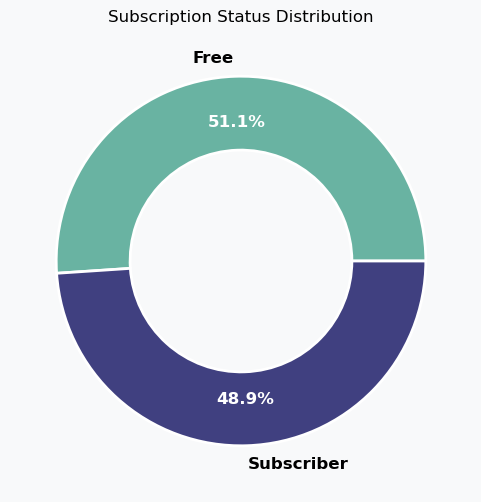

In [19]:
fig, ax = plt.subplots(figsize=(6, 6), facecolor='#f8f9fa')
ax.set_facecolor('#f8f9fa')

wedges, texts, autotexts = ax.pie(
    subscription_status_df['User_Count'],
    labels=subscription_status_df['SubscriptionStatus'],
    autopct='%1.1f%%',
    pctdistance=0.75,
    colors=["#69b3a2", "#404080"],
    textprops=dict(weight="bold", size=12),
    wedgeprops=dict(width=0.4, edgecolor='white', linewidth=2)
)

for autotext in autotexts:
    autotext.set_color("white")

plt.title("Subscription Status Distribution")
plt.show()

#### Horizontal Bar Chart

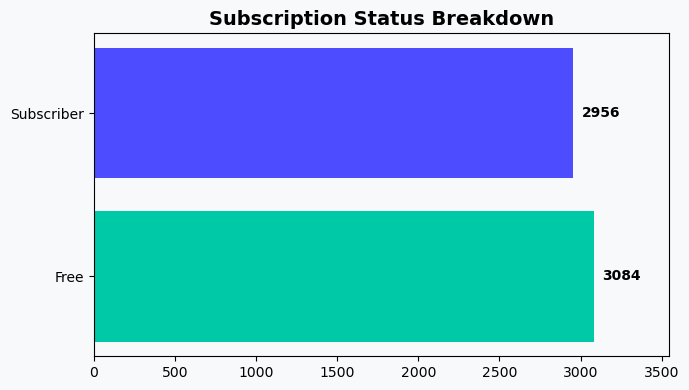

In [64]:
fig, ax = plt.subplots(figsize=(7, 4), facecolor="#f8f9fa")
ax.set_facecolor("#f8f9fa")

ax.barh(
    subscription_status_df['SubscriptionStatus'],
    subscription_status_df['User_Count'],
    color=["#00C9A7", "#4D4DFF"]
)

ax.set_title("Subscription Status Breakdown", fontsize=14, fontweight="bold")

# 1. Loop only handles adding the text labels
for i, v in enumerate(subscription_status_df['User_Count']):
    ax.text(v + 50, i, str(v), va='center', fontweight="bold")  # Increased padding slightly to v + 50

# 2. Dynamically expand the x-axis limit so the right-side numbers have breathing room
max_val = subscription_status_df['User_Count'].max()
ax.set_xlim(0, max_val * 1.15) 

# 3. Call tight_layout ONCE at the very end
plt.tight_layout()

plt.show()

In [44]:
import plotly.express as px

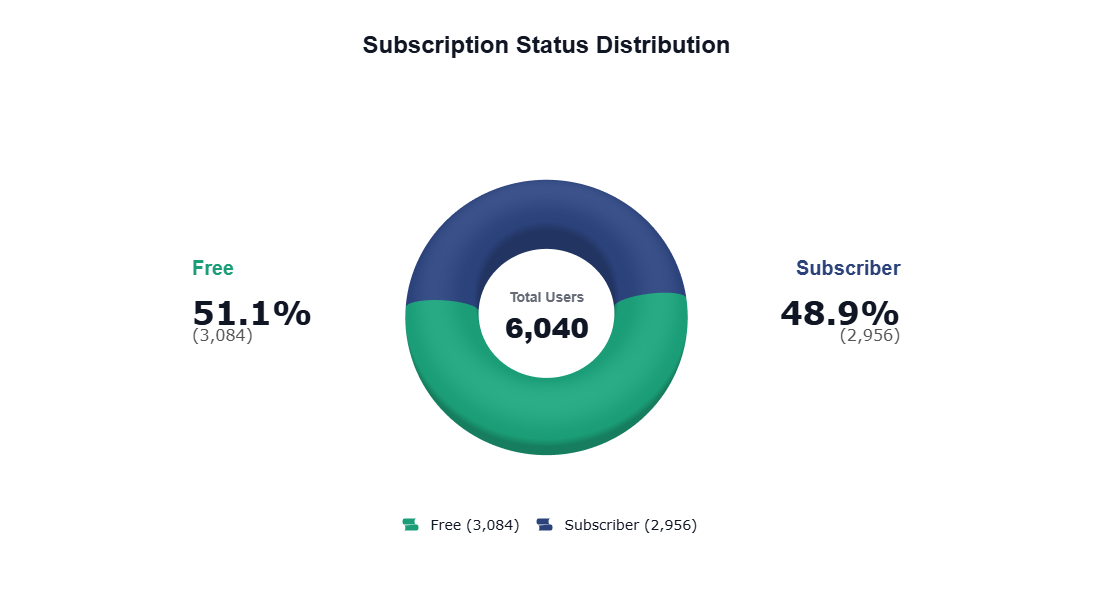

In [10]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go

# 1. Exact Input Data
data = {
    'Status': ['Free', 'Subscriber'],
    'Count': [3084, 2956]
}
df = pd.DataFrame(data)
total_users = df['Count'].sum()
percentages = [count / total_users for count in df['Count']]

# 2. Mathematical Mesh for a Scaled-Down 3D Donut Ring
def generate_smooth_donut(start_pct, end_pct, R=3.2, r=1.1, resolution=100):
    """
    Reduced radius values (R and r) to make the donut physically 
    smaller, leaving plenty of whitespace for the labels.
    """
    theta = np.linspace(start_pct * 2 * np.pi, end_pct * 2 * np.pi, resolution)
    phi = np.linspace(0, 2 * np.pi, resolution)
    theta, phi = np.meshgrid(theta, phi)
    
    X = (R + r * np.cos(phi)) * np.cos(theta)
    Y = (R + r * np.cos(phi)) * np.sin(theta)
    Z = r * np.sin(phi)
    return X, Y, Z

# 3. Initialize Figure
fig = go.Figure()

# Dashboard Color Palette: Emerald Green and Deep Navy Blue
colors = ['#1b9e77', '#2b427b'] 
current_pct = 0

for i, row in df.iterrows():
    next_pct = current_pct + percentages[i]
    X, Y, Z = generate_smooth_donut(current_pct, next_pct)
    
    legend_text = f"{row['Status']} ({row['Count']:,})"
    
    # Render the 3D surface mesh
    fig.add_trace(go.Surface(
        x=X, y=Y, z=Z,
        colorscale=[[0, colors[i]], [1, colors[i]]],
        showscale=False,
        name=legend_text,
        showlegend=True,
        hovertemplate=f"<b>{row['Status']}</b><br>Count: {row['Count']:,}<br>Share: {percentages[i]*100:.1f}%<extra></extra>"
    ))
    
    current_pct = next_pct

# 4. Clean Canvas Layout with Multi-layered, Non-overlapping Annotations
fig.update_layout(
    title=dict(
        text="<b>Subscription Status Distribution</b>",
        x=0.5, y=0.94,
        font=dict(size=24, color='#111625', family="Arial")
    ),
    annotations=[
        # --- CENTER INNER RING: "Total Users" ---
        dict(
            text="Total Users",
            showarrow=False,
            x=0.5, y=0.53,
            xref="paper", yref="paper",
            font=dict(size=14, color='#656a76', family="Arial", weight="bold"),
            align="center"
        ),
        # --- CENTER INNER RING: Number Count ---
        dict(
            text=f"{total_users:,}",
            showarrow=False,
            x=0.5, y=0.46,
            xref="paper", yref="paper",
            font=dict(size=28, color='#111625', family="Arial", weight=900),
            align="center"
        ),
        
        # --- LEFT SIDE: "Free" Label ---
        dict(
            text="Free",
            showarrow=False,
            x=0.05, y=0.60,
            xref="paper", yref="paper",
            font=dict(size=20, color='#1b9e77', family="Arial", weight="bold"),
            align="left"
        ),
        # --- LEFT SIDE: Percentage & Count ---
        dict(
            text=f"<span style='font-size:32px; font-weight:800; color:#111625;'>{percentages[0]*100:.1f}%</span><br><span style='color:#555555; font-size:16px;'>({df['Count'][0]:,})</span>",
            showarrow=False,
            x=0.05, y=0.48,
            xref="paper", yref="paper",
            align="left"
        ),
        
        # --- RIGHT SIDE: "Subscriber" Label ---
        dict(
            text="Subscriber",
            showarrow=False,
            x=0.95, y=0.60,
            xref="paper", yref="paper",
            font=dict(size=20, color='#2b427b', family="Arial", weight="bold"),
            align="right"
        ),
        # --- RIGHT SIDE: Percentage & Count ---
        dict(
            text=f"<span style='font-size:32px; font-weight:800; color:#111625;'>{percentages[1]*100:.1f}%</span><br><span style='color:#555555; font-size:16px;'>({df['Count'][1]:,})</span>",
            showarrow=False,
            x=0.95, y=0.48,
            xref="paper", yref="paper",
            align="right"
        )
    ],
    
    # 5. Fixed Aspect Window & Pulled-Back Camera (Makes Donut Smaller)
    scene=dict(
        xaxis=dict(visible=False),
        yaxis=dict(visible=False),
        zaxis=dict(visible=False),
        aspectmode='data',
        # Increased z value to 2.6 to shrink the chart and clear the sides entirely
        camera=dict(eye=dict(x=0.0, y=0.7, z=2.6))
    ),
    width=900,
    height=600,
    margin=dict(l=150, r=150, b=80, t=100), # Massive padding to isolate text callouts
    paper_bgcolor='#ffffff',
    
    # Bottom Horizontal Legend Box
    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=-0.05,
        xanchor="center",
        x=0.5,
        font=dict(size=14, color='#111625')
    )
    
)
# Render seamlessly inside your Jupyter Notebook
fig.show()